# Evaluacion 1 De Inteligencia Artificial


In [ ]:
!wget https://raw.githubusercontent.com/benjaminqq-12/Inteligencia-Artificial-2026-2/refs/heads/main/E1-EDA/rendimiento_academico_evaluacion.csv

--2026-09-03 00:41:46--  https://raw.githubusercontent.com/benjaminqq-12/Inteligencia-Artificial-2026-2/refs/heads/main/E1-EDA/rendimiento_academico_evaluacion.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 382638 (374K) [text/plain]
Saving to: ‘rendimiento_academico_evaluacion.csv’

rendimiento_academi 100%[===================>] 373.67K  --.-KB/s    in 0.05s   

2026-09-03 00:41:47 (6.70 MB/s) - ‘rendimiento_academico_evaluacion.csv’ saved [382638/382638]



In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

In [ ]:
data = pd.read_csv("rendimiento_academico_evaluacion.csv")
data.shape

(5100, 11)

# Diagnostico de Datos


In [9]:
null_summary = pd.DataFrame(
    {
        "Nulos_Absolutos": data.isnull().sum(),
        "Porcentaje_Nulos": round((data.isnull().sum() / len(data)) * 100, 2),
    }
)
print(null_summary[null_summary["Nulos_Absolutos"] > 0])
print("\n")

                      Nulos_Absolutos  Porcentaje_Nulos
Age                               103              2.02
StudyHours                        181              3.55
Attendance                        224              4.39
PreviousGPA                       162              3.18
AssignmentsCompleted              216              4.24
SleepHours                        122              2.39
InternetHours                     176              3.45
Scholarship                        81              1.59
Program                            70              1.37




In [10]:
total_duplicates = data.duplicated().sum()
print(f"Cantidad de filas duplicadas identificadas: {total_duplicates}")

Cantidad de filas duplicadas identificadas: 100


In [11]:
def diagnostico_outliers_iqr(dataframe: pd.DataFrame, columna: str):
  """
  Diagnóstico de valores atípicos

  Parámetros
  ----------
  dataframe: pd.DataFrame
    Set de datos a analizar
  columna: str
    Nombre de la columna a analizar

  Retorna
  -------
  outliers: pd.DataFrame
    Registros atípicos encontrados

  """
  Q1 = dataframe[columna].quantile(0.25)
  Q3 = dataframe[columna].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Aislamiento de registros atípicos
  outliers = dataframe[
        (dataframe[columna] < lower_bound) | (dataframe[columna] > upper_bound)
  ]

  print(f"--- Análisis IQR para la variable '{columna}' ---")
  print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
  print(f"Límite Inferior: {lower_bound:.2f} | Límite Superior: {upper_bound:.2f}")
  print(f"Registros fuera de límites: {len(outliers)} ({(len(outliers)/len(dataframe))*100:.2f}%)\n")
  return outliers

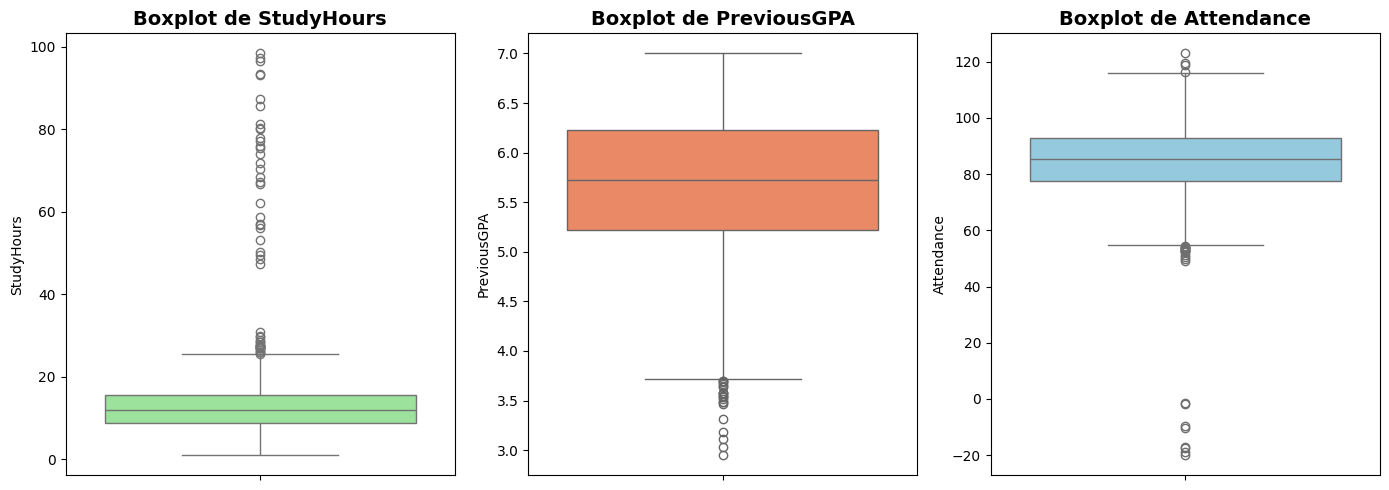

In [12]:
# 1. Generar Boxplots para StudyHours, PreviousGPA y Attendance
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.boxplot(y=data["StudyHours"], ax=axes[0], color="lightgreen")
axes[0].set_title("Boxplot de StudyHours", fontsize=14, fontweight="bold")

sns.boxplot(y=data["PreviousGPA"], ax=axes[1], color="coral")
axes[1].set_title("Boxplot de PreviousGPA", fontsize=14, fontweight="bold")

sns.boxplot(y=data["Attendance"], ax=axes[2], color="skyblue")
axes[2].set_title("Boxplot de Attendance", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [14]:
regla_gpa = (data["PreviousGPA"] < 1) | (data["PreviousGPA"] > 10)
regla_nota_final = (data["FinalGrade"] < 1) | (data["FinalGrade"] > 10)
regla_asistencia = (data["Attendance"] < 0) | (data["Attendance"] > 100)
regla_tareas = (data["AssignmentsCompleted"] < 0) | (data["AssignmentsCompleted"] > 100)
regla_horas = (data["StudyHours"] < 0) | (data["SleepHours"] < 0) | (data["SleepHours"] > 24) | (data["InternetHours"] < 0) | (data["InternetHours"] > 24)
regla_edad = (data["Age"] <= 0) | (data["Age"] > 100)

In [15]:
inconsistentes = data[regla_gpa | regla_nota_final | regla_asistencia | regla_tareas | regla_horas | regla_edad]
print(f"Registros inconsistentes encontrados: {len(inconsistentes)}")
display(inconsistentes)

Registros inconsistentes encontrados: 62


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
5,STU-11440,21.0,13.81,-19.961240,6.69,93.82,5.72,5.150000,Sí,Ingeniería Industrial,4.650000
16,STU-13555,26.0,6.08,111.567467,4.69,73.54,NaN,6.440000,No,Ingeniería Civil,3.050000
237,STU-10593,23.0,18.68,88.640000,6.69,100.00,5.34,68.116278,Sí,Ingeniería Industrial,4.910000
263,STU-12872,NaN,12.20,80.960000,5.54,81.02,6.82,1.530000,No,Ingeniería Civil,-1.328245
308,STU-14461,28.0,11.88,80.410000,5.61,76.94,7.33,48.616835,No,Contador Auditor,4.060000
...,...,...,...,...,...,...,...,...,...,...,...
4626,STU-13629,24.0,1.00,73.360000,4.05,67.69,5.94,30.729024,NaN,Ingeniería Informática,2.330000
4714,STU-10198,24.0,9.99,79.130000,5.90,72.76,5.39,59.249754,No,Administración,4.290000
4856,STU-12266,18.0,14.50,81.710000,6.82,100.00,7.79,50.412039,No,Ingeniería Informática,4.670000
4983,STU-12801,24.0,NaN,69.150000,4.40,74.96,7.82,67.001776,No,Ingeniería Informática,2.330000


In [16]:
print("Valores únicos en Program:", data["Program"].unique())
print("Valores únicos en Scholarship:", data["Scholarship"].unique())

Valores únicos en Program: ['Ingeniería Industrial' 'Ingeniería Informática' 'Contador Auditor'
 'Ingeniería Civil' 'Administración' nan 'INGENIERÍA INFORMÁTICA'
 'Ingeniería informática ' 'ADMINISTRACIÓN ' 'Ingenieria Informatica'
 'Administracion' 'Ingeniería Civil ' 'INGENIERÍA CIVIL']
Valores únicos en Scholarship: ['Sí' 'No' nan 'NO' 'si' 'SI' 'No ' 'SÍ ']


# Analisis exploratorio de datos

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudentID             5100 non-null   object 
 1   Age                   4997 non-null   float64
 2   StudyHours            4919 non-null   float64
 3   Attendance            4876 non-null   float64
 4   PreviousGPA           4938 non-null   float64
 5   AssignmentsCompleted  4884 non-null   float64
 6   SleepHours            4978 non-null   float64
 7   InternetHours         4924 non-null   float64
 8   Scholarship           5019 non-null   object 
 9   Program               5030 non-null   object 
 10  FinalGrade            5100 non-null   float64
dtypes: float64(8), object(3)
memory usage: 438.4+ KB


In [19]:
data.drop(columns=["StudentID", "FinalGrade"]).describe().round(3)

,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours
count,4997.000,4919.000,4876.000,4938.000,4884.000,4978.000,4924.000
mean,23.797,12.425,84.661,5.710,85.214,6.990,6.675
std,4.651,6.879,11.176,0.732,14.241,1.331,5.058
min,18.000,1.000,-19.961,2.950,25.340,-7.713,0.500
25%,21.000,8.750,77.578,5.220,75.848,6.160,3.800
50%,23.000,12.010,85.490,5.725,87.760,7.030,5.820
75%,26.000,15.440,93.010,6.230,100.000,7.860,8.390
max,80.000,98.329,122.974,7.000,100.000,11.000,69.501


In [20]:
data.drop(columns=["StudentID"]).describe(include="object")

,Scholarship,Program
count,5019,5030
unique,7,12
top,No,Ingeniería Informática
freq,3364,1424


In [21]:
# 1. Seleccionar subconjunto de variables numéricas continuas clave
numeric_cols = [
    "Age",
    "StudyHours",
    "Attendance",
    "PreviousGPA",
    "AssignmentsCompleted",
    "SleepHours",
    "InternetHours"
]

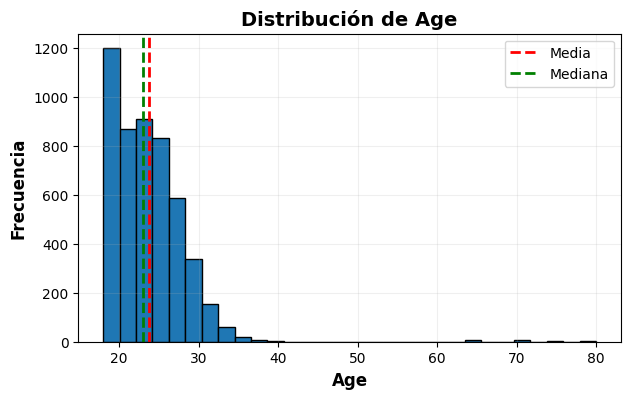

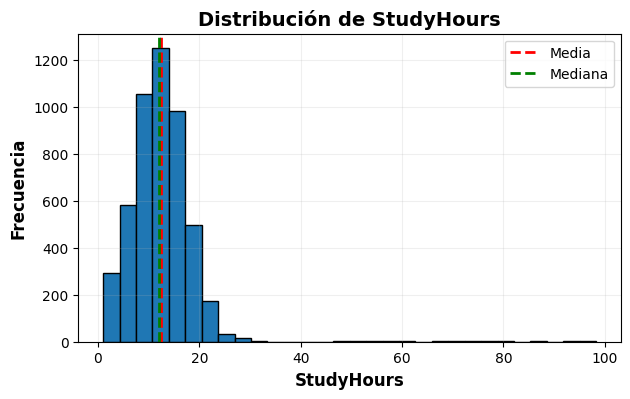

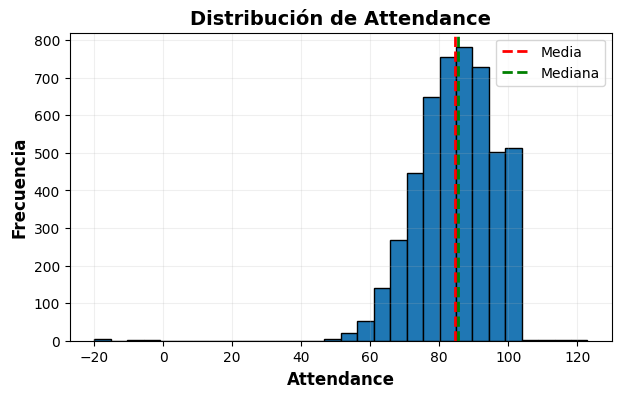

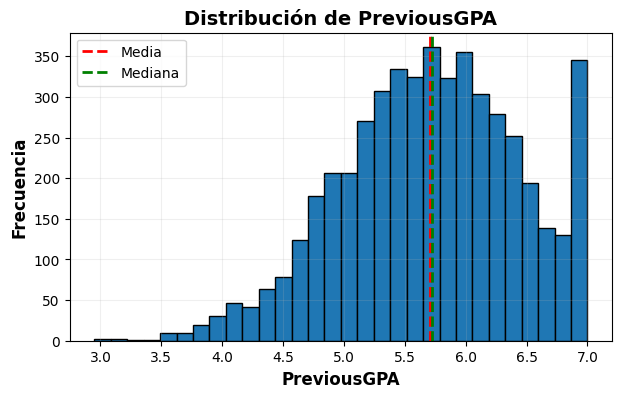

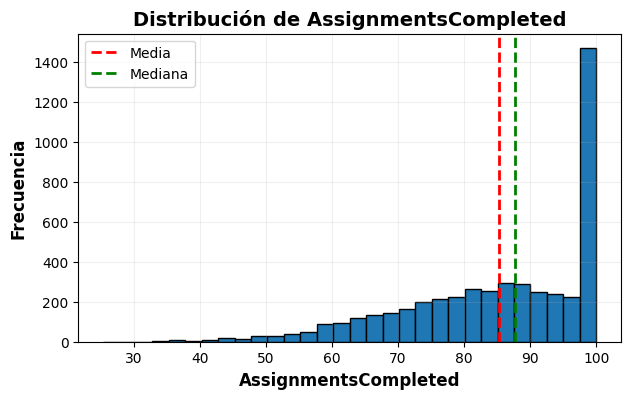

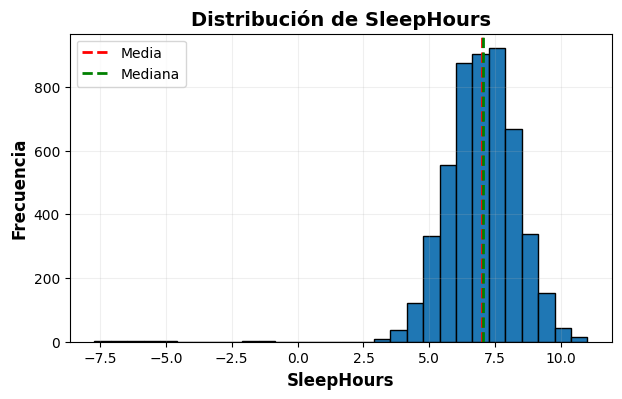

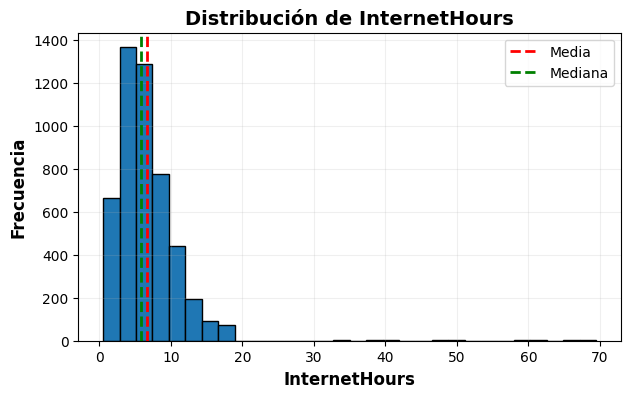

In [37]:
data_analisis = data.copy()
for variable in numeric_cols:

    plt.figure(figsize=(7, 4))

    plt.hist(data_analisis[variable].dropna(), bins=30, edgecolor="black")
    plt.axvline(data_analisis[variable].mean(), color="red", linestyle="dashed", linewidth=2, label="Media")
    plt.axvline(data_analisis[variable].median(), color="green", linestyle="dashed", linewidth=2, label="Mediana")

    # Agrega las etiquetas del label de media y mediana
    plt.legend()
    plt.title(f"Distribución de {variable}", fontsize=14, fontweight="bold")
    plt.xlabel(variable, fontsize=12, fontweight="bold")
    plt.ylabel("Frecuencia", fontsize=12, fontweight="bold")

    plt.grid(alpha=0.2)
    plt.show()

In [23]:
frecuencias_programa = data["Program"].value_counts().sort_index()

display(frecuencias_programa)

,count
Program,
ADMINISTRACIÓN,3
Administracion,3
Administración,787
Contador Auditor,660
INGENIERÍA CIVIL,4
INGENIERÍA INFORMÁTICA,7
Ingenieria Informatica,10
Ingeniería Civil,1004
Ingeniería Civil,5


In [24]:
porcentajes_programa = (
    data["Program"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

display(porcentajes_programa.round(2))

,proportion
Program,
ADMINISTRACIÓN,0.06
Administracion,0.06
Administración,15.65
Contador Auditor,13.12
INGENIERÍA CIVIL,0.08
INGENIERÍA INFORMÁTICA,0.14
Ingenieria Informatica,0.20
Ingeniería Civil,19.96
Ingeniería Civil,0.10


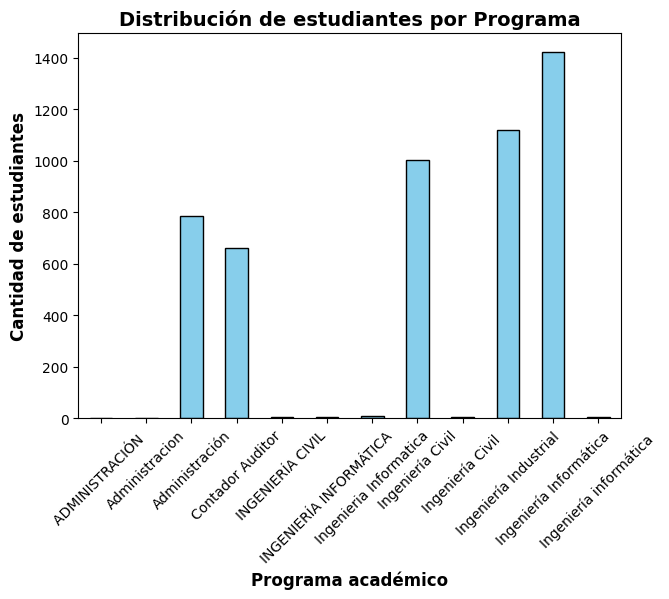

In [34]:
plt.figure(figsize=(7, 5))

data["Program"].value_counts().sort_index().plot(
    kind="bar", color="skyblue", edgecolor="black"
)

plt.title("Distribución de estudiantes por Programa", fontsize=14, fontweight="bold")
plt.xlabel("Programa académico", fontsize=12, fontweight="bold")
plt.ylabel("Cantidad de estudiantes", fontsize=12, fontweight="bold")
plt.xticks(rotation=45)

plt.show()

## Analisis bivariado

In [42]:
def scatter_plot(data: pd.DataFrame, x: str, y: str):
    """
    Genera un gráfico de dispersión (scatter plot) para dos variables.

    Parámetros
    ----------
    data: pd.DataFrame
        Set de datos a analizar
    x: str
        Nombre de la variable en el eje X
    y: str
        Nombre de la variable en el eje Y

    Retorna
    -------
    None
    """
    plt.figure(figsize=(8, 5))

    plt.scatter(data[x], data[y], alpha=0.5, color="purple")

    plt.xlabel(x, fontsize=14, fontweight="bold")
    plt.ylabel(y, fontsize=14, fontweight="bold")
    plt.title(f"{x} vs {y}", fontsize=16, fontweight="bold")

    plt.grid(alpha=0.2)

    plt.show()

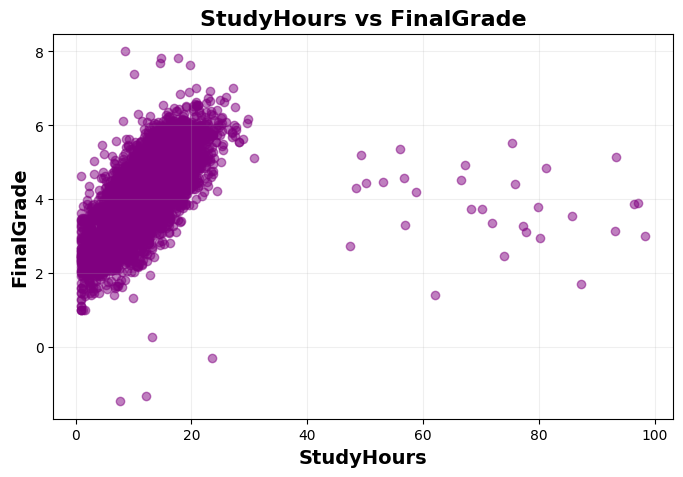

Correlación (StudyHours vs FinalGrade): 0.4905


In [43]:
# Analizar Horas de Estudio vs Nota Final
scatter_plot(data, "StudyHours", "FinalGrade")

print(f"Correlación (StudyHours vs FinalGrade): {data['StudyHours'].corr(data['FinalGrade']):.4f}")

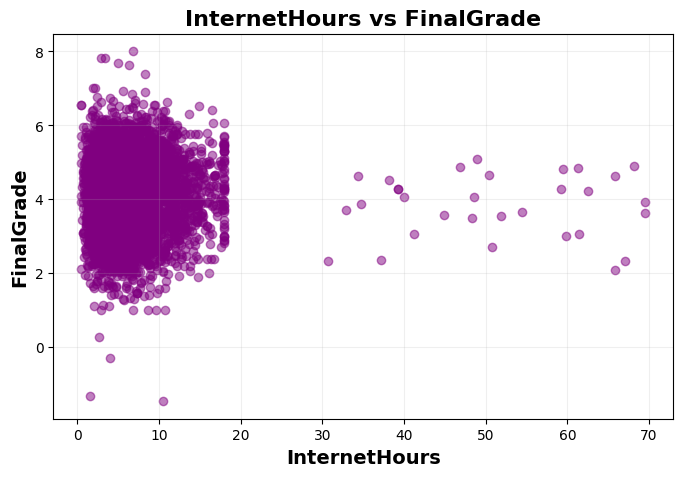

Correlación (Attendance vs FinalGrade): 0.5852


In [47]:
# Analizar Asistencia vs Nota Final
scatter_plot(data, "InternetHours", "FinalGrade")

print(f"Correlación (Attendance vs FinalGrade): {data['Attendance'].corr(data['FinalGrade']):.4f}")

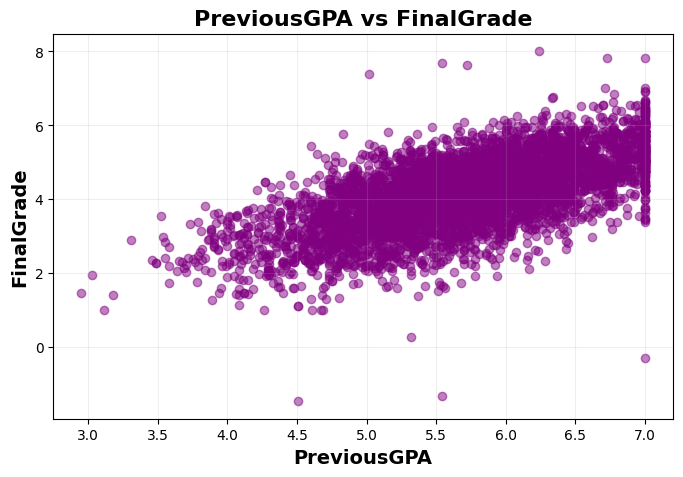

Correlación (PreviousGPA vs FinalGrade): 0.6531


In [45]:
# Analizar Promedio Previo vs Nota Final
scatter_plot(data, "PreviousGPA", "FinalGrade")

print(f"Correlación (PreviousGPA vs FinalGrade): {data['PreviousGPA'].corr(data['FinalGrade']):.4f}")

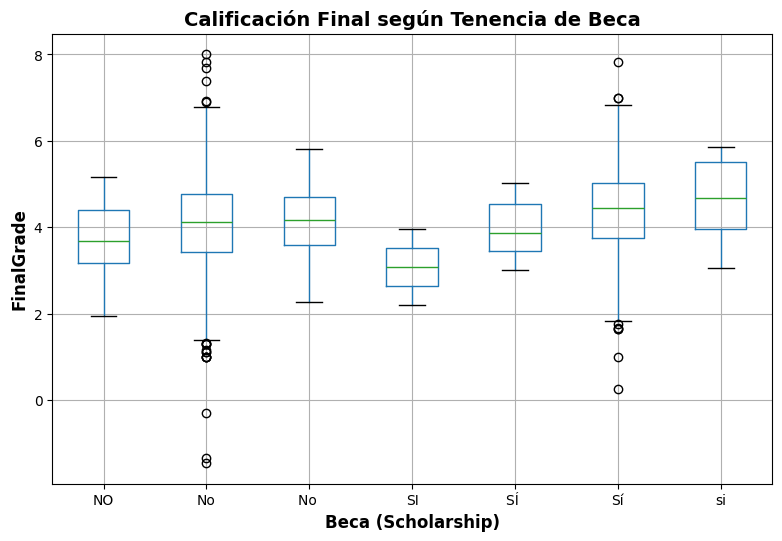

In [48]:
fig, ax = plt.subplots(figsize=(9, 6))

data.boxplot(column="FinalGrade", by="Scholarship", ax=ax)

ax.set_title("Calificación Final según Tenencia de Beca", fontsize=14, fontweight="bold")
ax.set_xlabel("Beca (Scholarship)", fontsize=12, fontweight="bold")
ax.set_ylabel("FinalGrade", fontsize=12, fontweight="bold")

fig.suptitle("")
plt.show()

In [26]:
resumen_beca = (
    data.groupby("Scholarship")["FinalGrade"]
    .agg(["count", "mean", "median", "std"])
)

display(resumen_beca.round(2))

,count,mean,median,std
Scholarship,,,,
NO,8,3.73,3.68,1.05
No,3364,4.07,4.12,1.00
No,10,4.10,4.16,1.17
SI,2,3.08,3.08,1.23
SÍ,5,3.98,3.88,0.81
Sí,1620,4.37,4.44,0.93
si,10,4.64,4.69,1.00


In [25]:
resumen_programa = (
    data.groupby("Program")["FinalGrade"]
    .agg(["count", "mean", "median", "std"])
)

display(resumen_programa.sort_values(by="mean", ascending=False).round(2))

,count,mean,median,std
Program,,,,
Ingeniería Civil,5,4.63,4.83,0.83
Ingeniería informática,4,4.25,4.22,0.66
Ingeniería Informática,1424,4.23,4.28,0.99
Ingenieria Informatica,10,4.22,4.27,1.14
Administración,787,4.22,4.28,1.01
Ingeniería Industrial,1119,4.20,4.28,0.98
Ingeniería Civil,1004,4.11,4.19,0.99
INGENIERÍA INFORMÁTICA,7,4.11,4.23,0.60
Contador Auditor,660,4.05,4.04,1.00


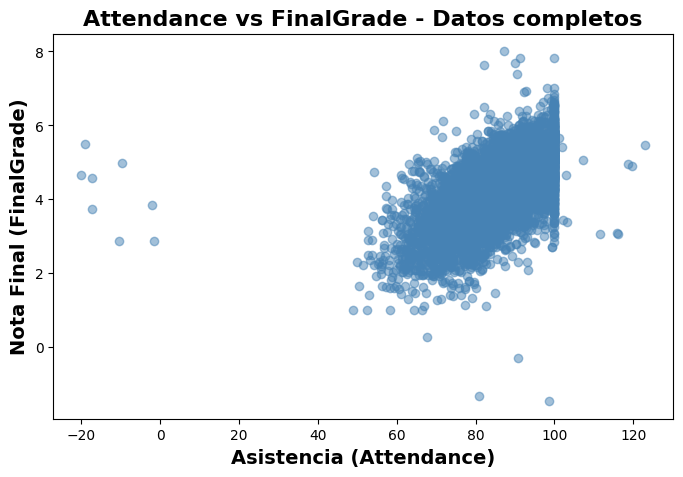

In [49]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data["Attendance"],
    data["FinalGrade"],
    alpha=0.5,
    color="steelblue"
)

plt.xlabel("Asistencia (Attendance)", fontsize=14, fontweight="bold")
plt.ylabel("Nota Final (FinalGrade)", fontsize=14, fontweight="bold")
plt.title("Attendance vs FinalGrade - Datos completos", fontsize=16, fontweight="bold")

plt.show()

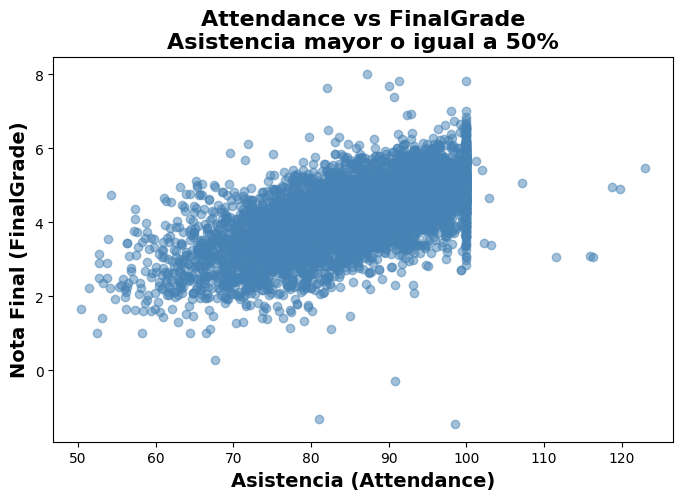

In [50]:
# Filtrar estudiantes con asistencia igual o superior al 50%
data_sin_extremos = data[data["Attendance"] >= 50]

plt.figure(figsize=(8, 5))

plt.scatter(
    data_sin_extremos["Attendance"],
    data_sin_extremos["FinalGrade"],
    alpha=0.5,
    color="steelblue"
)

plt.xlabel("Asistencia (Attendance)", fontsize=14, fontweight="bold")
plt.ylabel("Nota Final (FinalGrade)", fontsize=14, fontweight="bold")
plt.title("Attendance vs FinalGrade\nAsistencia mayor o igual a 50%", fontsize=16, fontweight="bold")

plt.show()

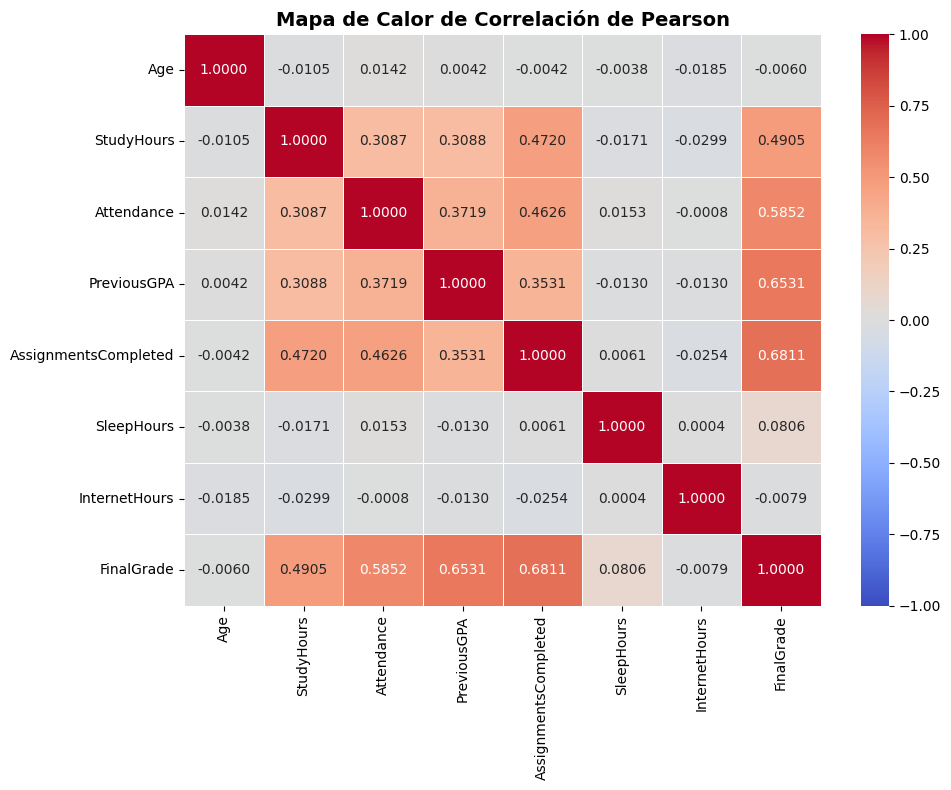

In [51]:
# Definir las variables numéricas incluyendo la nota final para ver sus correlaciones
columnas_heatmap = [
    "Age", "StudyHours", "Attendance", "PreviousGPA",
    "AssignmentsCompleted", "SleepHours", "InternetHours", "FinalGrade"
]
data_numeric = data[columnas_heatmap]

# Calcular Coeficiente de Correlación de Pearson y dibujar Heatmap
correlation_matrix = data_numeric.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Mapa de Calor de Correlación de Pearson", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Definicion de Variables dependiente Y e independientes X

In [52]:
# Elimina el ID del estudiante (no aporta al modelo) y la variable objetivo
X = data.drop(columns=["StudentID", "FinalGrade"])

# Aislar la variable objetivo
y = data["FinalGrade"]

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=29
)

print(f"Dataset de Entrenamiento (X_train): {X_train.shape}")
print(f"Dataset de Prueba (X_test): {X_test.shape}\n")

Dataset de Entrenamiento (X_train): (4080, 9)
Dataset de Prueba (X_test): (1020, 9)



## Definicion de Sub-Pipelines por tipo de variable

In [54]:
# A. Variables numéricas normales (sin presencia severa de outliers)
num_standard_features = ["StudyHours", "Attendance", "AssignmentsCompleted", "SleepHours", "InternetHours"]
num_standard_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),  # Imputación por media
        ("scaler", StandardScaler()),  # Escalado estándar (Z-score)
    ]
)

# B. Variables numéricas con presencia de Outliers severos
# (Pon aquí las variables que te dieron muchos puntos fuera de la caja en los boxplots)
num_robust_features = ["Age", "PreviousGPA"]
num_robust_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")), # Imputación por mediana
        ("scaler", RobustScaler()),  # Escalador resistente a outliers
    ]
)

# C. Variables categóricas
categorical_features = ["Scholarship", "Program"]
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),  # Imputación por moda
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# Integración con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num_std", num_standard_pipeline, num_standard_features),
        ("num_robust", num_robust_pipeline, num_robust_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="passthrough"
)

In [55]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num_std',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['StudyHours', 'Attendance',
                                  'AssignmentsCompleted', 'SleepHours',
                                  'InternetHours']),
                                ('num_robust',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['Age', 'PreviousGPA']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Scholarship', 'Program'])])

## Ajuste y Transformacion de Datos

In [56]:
# Fit y Transform SOLO sobre el conjunto de Entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# Transform (NUNCA FIT) sobre el conjunto de Prueba
X_test_processed = preprocessor.transform(X_test)

# Obtener nombres de columnas procesadas para las variables categóricas (OneHotEncoding)
encoded_cat_cols = (
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

# Unir todos los nombres en el orden exacto en el que el ColumnTransformer los escupe
all_feature_names = (
    num_standard_features
    + num_robust_features
    + list(encoded_cat_cols)
)

In [57]:
all_feature_names

['StudyHours',
 'Attendance',
 'AssignmentsCompleted',
 'SleepHours',
 'InternetHours',
 'Age',
 'PreviousGPA',
 'Scholarship_NO',
 'Scholarship_No',
 'Scholarship_No ',
 'Scholarship_SI',
 'Scholarship_SÍ ',
 'Scholarship_Sí',
 'Scholarship_si',
 'Program_ADMINISTRACIÓN ',
 'Program_Administracion',
 'Program_Administración',
 'Program_Contador Auditor',
 'Program_INGENIERÍA CIVIL',
 'Program_INGENIERÍA INFORMÁTICA',
 'Program_Ingenieria Informatica',
 'Program_Ingeniería Civil',
 'Program_Ingeniería Civil ',
 'Program_Ingeniería Industrial',
 'Program_Ingeniería Informática',
 'Program_Ingeniería informática ']

In [58]:
X_train_processed.shape

(4080, 26)

In [59]:
# Convertir la matriz matemática de vuelta a un DataFrame de Pandas para poder leerlo
X_train_prep = pd.DataFrame(X_train_processed, columns=all_feature_names)

# Vista previa de los datos limpios y transformados
X_train_prep.head()

,StudyHours,Attendance,AssignmentsCompleted,SleepHours,InternetHours,Age,PreviousGPA,Scholarship_NO,Scholarship_No,Scholarship_No,...,Program_Administración,Program_Contador Auditor,Program_INGENIERÍA CIVIL,Program_INGENIERÍA INFORMÁTICA,Program_Ingenieria Informatica,Program_Ingeniería Civil,Program_Ingeniería Civil,Program_Ingeniería Industrial,Program_Ingeniería Informática,Program_Ingeniería informática
0,-0.508821,-0.078342,0.985760,0.722479,0.057990,-0.4,0.824742,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.588727,0.095865,-0.279660,-0.474809,0.249985,0.2,-0.226804,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.837827,0.819424,1.057562,0.105010,-0.499993,0.0,0.484536,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.792536,-0.247019,-0.120416,-0.226315,1.307952,0.0,-0.030928,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.037106,0.824954,1.057562,0.112540,0.511977,-0.2,-0.381443,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
